# Project of handwritten recognition using CNN

starting I import all the libraries that were required including the torch, torchvision for the working on CNN, torchvision for transformation and matplotlib for visualization of the data.

In [5]:
!pip install torch torchvision torchaudio
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   - -------------------------------------- 3.7/122.1 MB 17.4 MB/s eta 0:00:07
   --- ------------------------------------ 9.4/122.1 MB 17.1 MB/s eta 0:00:07
   ---- ----------------------------------- 14.9/122.1 MB 17.5 MB/s eta 0:00:07
   ------ --------------------------------- 19.1/122.1 MB 17.9 MB/s eta 0:00:06
   ------- -------------------------------- 21.8/122.1 MB 16.9 MB/s eta 0:00:06
   -------- ------------------------------- 24.9/122.1 MB 16.7 MB/s eta 0:00:06
   --------- ------------------------------ 28.8/122.1 MB 16.8 MB/s eta 0:00:06
   ---------- ----------------------------- 33.0/122.1 MB 16.9 MB/s eta 0:00:06
   ------------ --------------------------- 37.2/122.1 MB 17.1 MB/s eta 0:00:05
   ------------- -------------------------- 41.7/122.1 MB 17.1 MB/s eta 0:00:05
   --------------- ------------------------ 45.9/122.1 MB 17.1 MB/s eta 0:00:05
   ---------------- ----------------------- 49.5/12

Checking if gpu is present on the device for working

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Variable for the task

In [ ]:
input_size = 28*28 
hidden_size = 100
num_classes = 10
num_epochs = 2
batch_size = 100
learning_rate = 0.001

Downloading the training and testing dataset. Here using the MNIST inbuild dataset from pytorch.

In [9]:
train_dataset = torchvision.datasets.MNIST(root='./data',train=True, transform= transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.MNIST(root='./data',train=False, transform= transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


100.0%
100.0%
100.0%
100.0%


Tensor transformation and normalisation of the data

In [11]:
# Preprocessing: Transformation and Normalization
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize with mean and std of MNIST
    ])

Visualising the data through the sample and further analysing it

torch.Size([100, 1, 28, 28]) torch.Size([100])


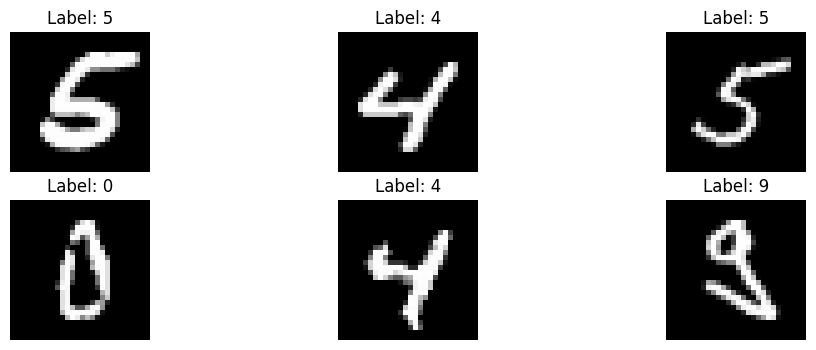

In [12]:
examples = iter(train_loader)
samples, labels = next(examples)
print(samples.shape, labels.shape)

plt.figure(figsize=(12,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(samples[i][0], cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()


Following on I tried to implement the Actual CNN architecture

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()

        # Convolutional Layer 1
        self.conv1 = nn.Conv2d(in_channels=1,out_channels=16,kernel_size=5,stride=1,padding=2) #params

        # Convolutional Layer 2
        self.conv2 = nn.Conv2d(in_channels=16,out_channels=32,kernel_size=5,stride=1,padding=2) #params

        # Max Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        self.fc1 = nn.Linear(32 * 7 * 7, 100)
        self.fc2 = nn.Linear(100, 10)

        # LogSoftmax for multi-class classification
        self.output_activation = nn.LogSoftmax(dim=1)

    def forward(self, x):
        # First Convolution -> ReLU -> Pooling
        x = self.pool(F.relu(self.conv1(x)))

        # Second Convolution -> ReLU -> Pooling
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten the tensor
        x = x.view(x.size(0), -1)

        # Fully Connected Layer 1
        x = F.relu(self.fc1(x))

        # Output Layer
        x = self.output_activation(self.fc2(x))

        return x

Then I defined the model for this CNN along with the loss and optimizer functions

I also trained it on the given dataset to establish the results which can be seen in the output of the following code.

In [14]:
model = MNIST_CNN().to(device)
criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# Training the model
num_epochs = 2
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

Epoch [1/2], Step [100/600], Loss: 0.3788
Epoch [1/2], Step [200/600], Loss: 0.1125
Epoch [1/2], Step [300/600], Loss: 0.2461
Epoch [1/2], Step [400/600], Loss: 0.1263
Epoch [1/2], Step [500/600], Loss: 0.0510
Epoch [1/2], Step [600/600], Loss: 0.0302
Epoch [2/2], Step [100/600], Loss: 0.0595
Epoch [2/2], Step [200/600], Loss: 0.0371
Epoch [2/2], Step [300/600], Loss: 0.0742
Epoch [2/2], Step [400/600], Loss: 0.0055
Epoch [2/2], Step [500/600], Loss: 0.0582
Epoch [2/2], Step [600/600], Loss: 0.0153


Following this let us try to analyse the performance based on the confusion matrix which can be done using the sklearn library.

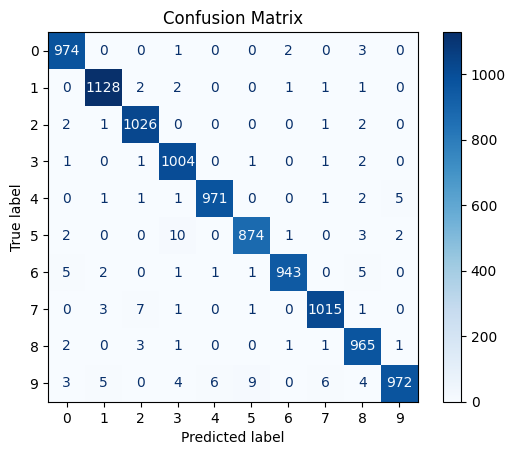

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming you have the trained model and test_loader
import torch

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
